In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
print(os.path.abspath("rl_project.ipynb"))

C:\Users\baugh\thermostat\rl_project.ipynb


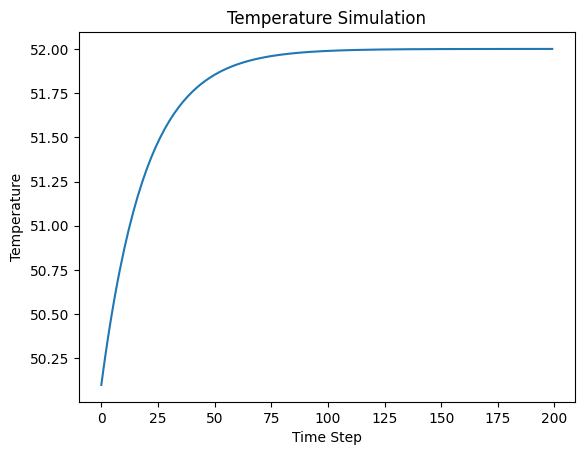

In [2]:
T = 50
T_env = 50
heater_power = 1
alpha = 0.1
beta = 0.05

temps = []
for t in range(200):
    T = T + alpha*heater_power - beta*(T - T_env)
    temps.append(T)

plt.plot(temps)
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.title("Temperature Simulation")
plt.show()

In [6]:
target_temp = 70
actions = [0, 0.5, 1]
reward = -abs(T - target_temp)

In [127]:
class TempEnv:
    def __init__(self, target=25):
        self.T_env = 20
        self.alpha = 0.2
        self.actions = [-1, -0.5, 0, 0.5, 1]
        self.target = target
        self.reset()

    def reset(self):
        self.T = np.random.uniform(0,49)
        self.beta = np.random.uniform(0.02,0.04)
        return self.T

    def step(self, action):
        power = self.actions[action]
        self.T = self.T + self.alpha*power - self.beta*(self.T - self.T_env)

        reward = -abs(self.T - self.target) - 0.2*abs(power)

        done = False

        return self.T, reward, done

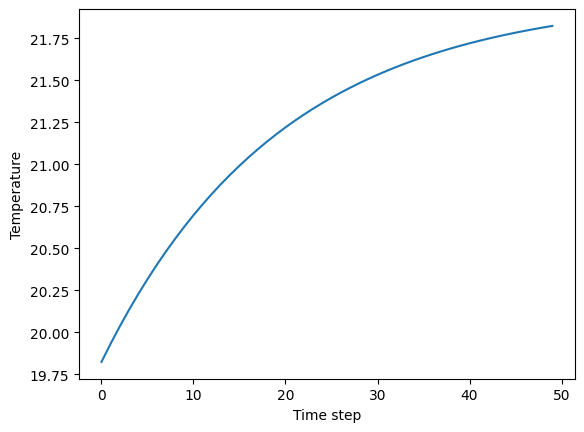

In [49]:
env = TempEnv(target=25)
state = env.reset()
temps = []

for _ in range(50):
    action = 2
    state, reward, done = env.step(action)
    temps.append(state)

plt.plot(temps)
plt.xlabel("Time step")
plt.ylabel("Temperature")
plt.show()

Episode: 0 Reward: -1020.6612288440979
Episode: 100 Reward: -648.8249555236205
Episode: 200 Reward: -295.5700390049546
Episode: 300 Reward: -92.99924976202972
Episode: 400 Reward: -469.3543933139132
Episode: 500 Reward: -383.97360622794343
Episode: 600 Reward: -72.14788692237309
Episode: 700 Reward: -967.5147910998776
Episode: 800 Reward: -184.59434372132466
Episode: 900 Reward: -509.6200393004405
Training Complete
Step: 0 Temp: 21.455313769561034 Power: 1
Step: 1 Temp: 21.620973416717597 Power: 1
Step: 2 Temp: 21.782724071288325 Power: 1
Step: 3 Temp: 21.940657971928186 Power: 1
Step: 4 Temp: 22.094865180780097 Power: 1
Step: 5 Temp: 22.245433634833052 Power: 1
Step: 6 Temp: 22.39244919606838 Power: 1
Step: 7 Temp: 22.535995700422717 Power: 1
Step: 8 Temp: 22.676155005595632 Power: 1
Step: 9 Temp: 22.81300703772915 Power: 1
Step: 10 Temp: 22.946629836985814 Power: 1
Step: 11 Temp: 23.07709960205124 Power: 1
Step: 12 Temp: 23.2044907335866 Power: 1
Step: 13 Temp: 23.328875876655722 Pow

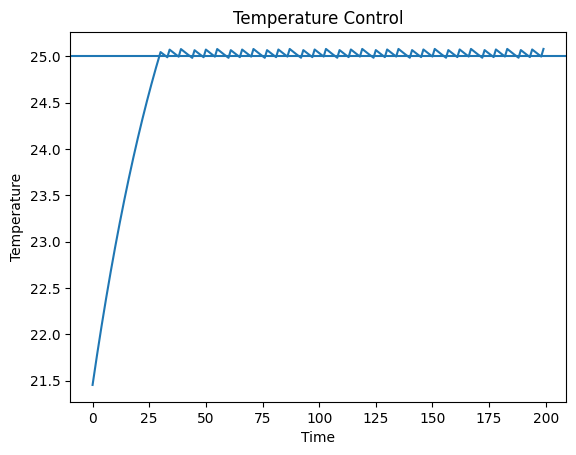

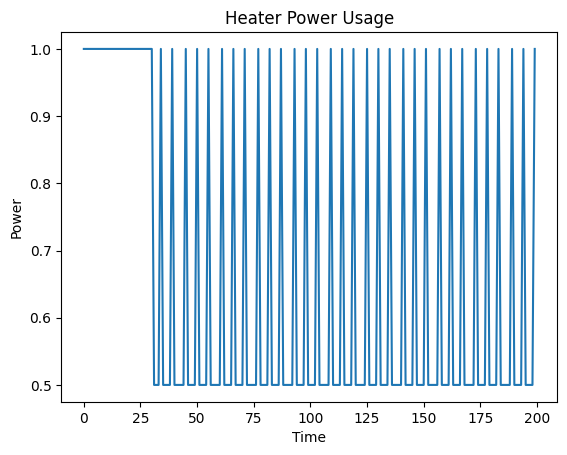

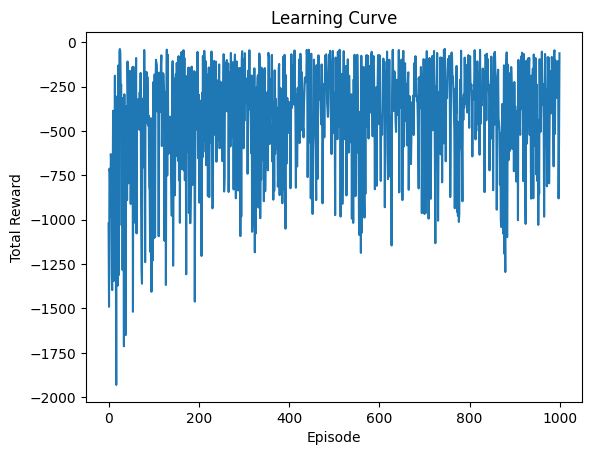

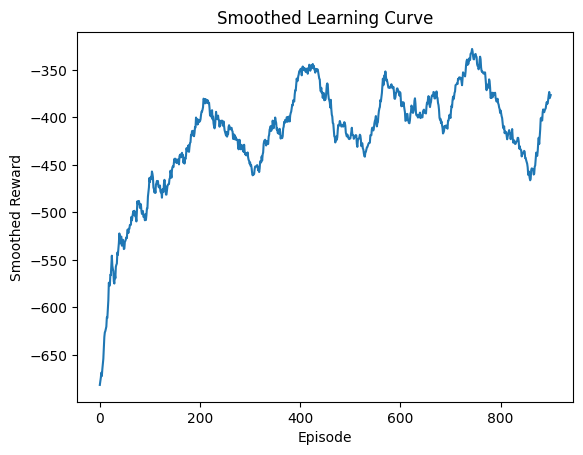

In [128]:
def get_state(temp):
    return int(np.clip(temp, 0, 49))

env = TempEnv()
num_states = 50
num_actions = 5
Q = np.zeros((num_states, num_actions))

alpha = 0.1
gamma = 0.9
epsilon = 0.1

episodes = 1000
episode_rewards = []

for episode in range(episodes):
    state = get_state(env.reset())
    total_reward = 0

    for t in range(200):
        if np.random.rand() < epsilon:
            action = np.random.randint(num_actions)
        else:
            action = np.argmax(Q[state])

        next_temp, reward, done = env.step(action)
        total_reward += reward
        next_state = get_state(next_temp)

        best_next = np.max(Q[next_state])
        Q[state, action] = Q[state, action] + alpha*(reward + gamma*best_next - Q[state, action])
        state = next_state

    episode_rewards.append(total_reward)
    if episode % 100 == 0:
        print("Episode:", episode, "Reward:", total_reward)
print("Training Complete")

temps = []
powers = []

state = get_state(env.reset())

for t in range(200):
    action = np.argmax(Q[state])
    temp, reward, done = env.step(action)
    power = env.actions[action]

    print("Step:", t, "Temp:", temp, "Power:", power)
    temps.append(temp)
    powers.append(power)

    state = get_state(temp)

plt.figure()
plt.plot(temps)
plt.axhline(env.target)
plt.title("Temperature Control")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

plt.figure()
plt.plot(powers)
plt.title("Heater Power Usage")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()

plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Learning Curve")
plt.show()

window = 100
smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
plt.figure()
plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Reward")
plt.title("Smoothed Learning Curve")
plt.show()